# Exercise 13:  Resampling methods

This homework assignment is designed to give you practice with bootstrapping and permutation tests.

You will need to download the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file from the *Homework/hcp_data* folder in the class GitHub repository.

This data is a portion of the [Human Connectome Project database](http://www.humanconnectomeproject.org/). It provides measures of cognitive tasks and brain morphology measuresments from 1206 participants. The full description of each variable is provided in the **HCP_S1200_DataDictionary_April_20_2018.csv** file in the *Homework/hcp_data* folder in the class GitHub repository.

1. Loading and visualizing data 1/1
2. Logistic classifier 2/2
3. Bootstrapped accuracy 3/3
4. Permutation test for grey matter effects 3/3
5. Reflection 1/1

---
## 1. Loading & Visualizing the Data (1 point)

Use the `setwd` and `read.csv` functions to load data from the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file.

(a) Using the tidyverse tools, make a new dataframe `d1` that only inclues the subject ID (`Subject`), gender (`Gender`, self reported at time of data collection), Flanker Task performance (`Flanker_Unadj`), total intracranial volume (`FS_IntraCranial_Vol`), total white matter volume (`FS_Tot_WM_Vol`), and total grey matter volume (`FS_Total_GM_Vol`) variables and remove all _na_ values.

Use the `head` function to look at the first few rows of each data frame.

In [ ]:
# WRITE YOUR CODE HERE
library(dplyr)
path <- '/Users/george/Library/CloudStorage/GoogleDrive-hyabuki@andrew.cmu.edu/My Drive/Coursework/DSPN Homework datasets/hcp_data/'
setwd(path)
df <- read.csv('unrestricted_trimmed_1_7_2020_10_50_44.csv')

In [ ]:
d1 <- df %>% select(c(Subject, Gender, Flanker_Unadj, FS_IntraCranial_Vol, FS_Tot_WM_Vol, FS_Total_GM_Vol))%>%na.omit
head(d1)

,Subject,Gender,Flanker_Unadj,FS_IntraCranial_Vol,FS_Tot_WM_Vol,FS_Total_GM_Vol
,<int>,<chr>,<dbl>,<dbl>,<int>,<int>
2,100206,M,130.42,1864518,543134,807245
3,100307,F,112.56,1512540,407292,664124
4,100408,M,121.18,1684117,500417,726206
5,100610,M,126.53,1816044,512946,762308
6,101006,F,101.85,1437868,429449,579632
7,101107,M,107.04,1512727,416995,665024


(b) Plot grey matter volume (x axis) against intracranial volume (y axis) and Gender (point color).

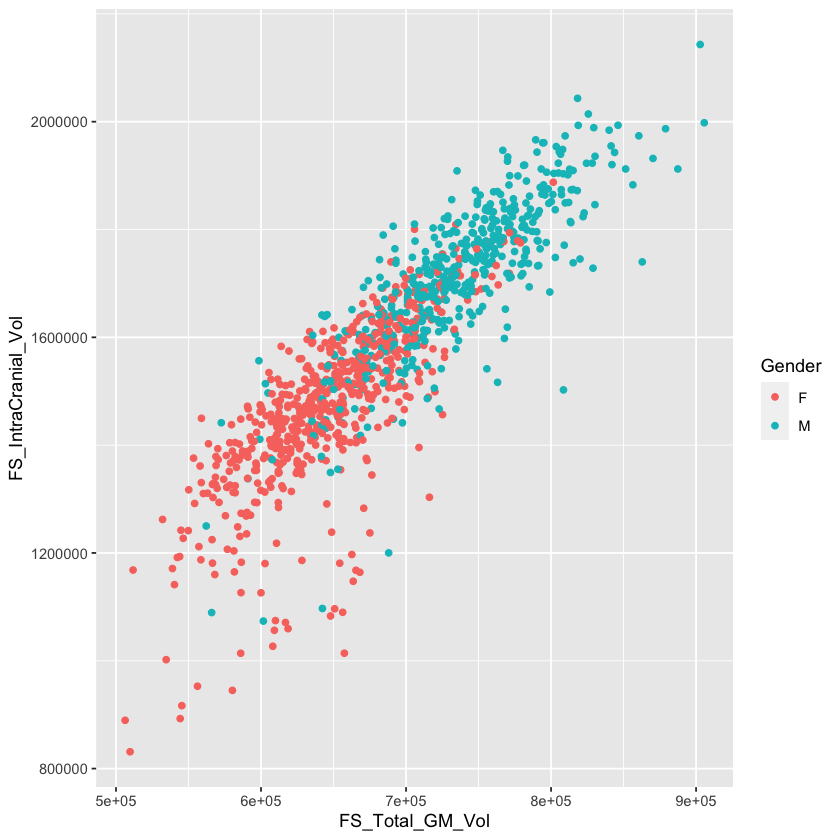

In [ ]:
# WRITE YOUR CODE HERE
library(ggplot2)
ggplot(d1, aes(x = FS_Total_GM_Vol, y = FS_IntraCranial_Vol, color = Gender))+
geom_point()

What patterns do you observe in the scatter plot?

> positive relationship between intracranial volume and total grey matter volume. women tend to have lower amounts, men tend to have higher amounts.

---
## 2. Logistic classifier (2 points)

We want to try predicting gender using the neural data you have loaded.

(a) Run a logisic regression model to predict gender from total white matter volume, total grey matter volume, and intracranial volume.

In [ ]:
# WRITE YOUR CODE HERE
d1 <- d1 %>% mutate(Gender = if_else(Gender == 'F', 1, 0))
mod_1 <- glm(Gender ~ FS_IntraCranial_Vol + FS_Tot_WM_Vol + FS_Total_GM_Vol, data = d1, family = binomial)
summary(mod_1)


Call:
glm(formula = Gender ~ FS_IntraCranial_Vol + FS_Tot_WM_Vol + 
    FS_Total_GM_Vol, family = binomial, data = d1)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)          2.262e+01  1.347e+00  16.787  < 2e-16 ***
FS_IntraCranial_Vol -5.020e-06  1.177e-06  -4.263 2.01e-05 ***
FS_Tot_WM_Vol       -2.140e-06  3.059e-06  -0.699    0.484    
FS_Total_GM_Vol     -1.959e-05  3.145e-06  -6.229 4.70e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1534.13  on 1112  degrees of freedom
Residual deviance:  919.85  on 1109  degrees of freedom
AIC: 927.85

Number of Fisher Scoring iterations: 5


Which factors are signficantly associated with gender?

> Intracranial volume and the total grey matter volume.

(b) Estimate the prediction accuracy of your model (Note: this is the training set accuracy). Set your prediction threshold to 0.5.

In [ ]:
# WRITE YOUR CODE HERE
test_df <- data.frame(predicted_accr = predict(mod_1, type = 'response'))
threshold <- 0.50
num_observations = nrow(test_df)

In [ ]:
test_df$predicted_binary = rep("0",num_observations)
test_df$predicted_binary[test_df$predicted_accr>threshold]="1" #find the rows that have prob > threshold and cast as '1'
head(test_df)

,predicted_accr,predicted_binary
,<dbl>,<chr>
2,0.02366135,0
3,0.75792878,1
4,0.24316721,0
5,0.07366525,0
6,0.95787337,1
7,0.75063972,1


In [ ]:
#confusion matrix
confusion_df = data.frame(test_df$predicted_binary, d1$Gender)
colnames(confusion_df) = c('predicted', 'actual')
table(confusion_df)
accr <- mean(confusion_df$predicted == confusion_df$actual)
#overall accuracy for predictions
print(paste("Accuracy: ", accr))

         actual
predicted   0   1
        0 397  90
        1 110 516

[1] "Accuracy:  0.820305480682839"


What is the prediction accuracy for gender from the full model?

> About 82%.

---
## 3. Bootstrapped accuracy (3 points)

Use bootstrapping to estimate the confidence intervals of the _prediction accuracy_ of your model (i.e., the confidence of the correlation between $\hat{y}$ and $y$). Plot the histogram of the bootstrapped prediction accuracies and estimate the confidence intervals off of the standard deviation from the bootstrap.


In [ ]:
# WRITE YOUR CODE HERE
library(boot)

In [ ]:

boot.fn <- function(dat, ind){
   df <- dat[ind,]
   mod <- glm(Gender ~ FS_IntraCranial_Vol + FS_Tot_WM_Vol + FS_Total_GM_Vol, data = df, family = binomial)
   test_df$predicted_accr <- predict(mod, type = 'response')
   threshold <- 0.50
   num_observations = nrow(test_df)
   test_df$predicted_binary = rep("0", num_observations)
   test_df$predicted_binary[test_df$predicted_accr>threshold]="1"
   confusion_df = data.frame(test_df$predicted_binary, df$Gender)
   colnames(confusion_df) = c('predicted', 'actual')
   x <- mean(confusion_df$predicted == confusion_df$actual)
   return(x)
}

In [ ]:
boot_obj <- boot(d1, boot.fn, R=1000)
#attributes(boot_obj)

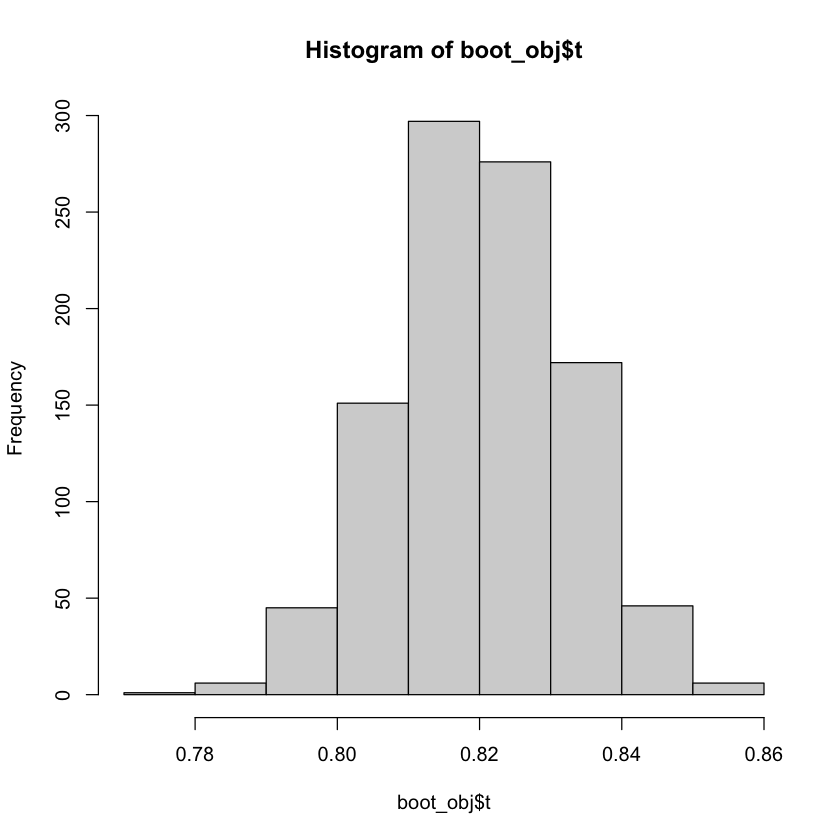

In [ ]:
hist(boot_obj$t)

> Based on the spread of the boostrapped model accuracies, the 95% confidence interval seems to be between 0.79 - 0.85.

How robust is the prediction accuracy of the full model?

> Pretty robust - most of the predicted accuracies cluster around 0.82, as indicated by the highest frequency in the histogram.

---
## 4. Permutation test for grey matter effects (3 points)

Now run a permutation test, with 1000 iterations, to evaluate how much grey matter volume contributes to the prediction accuracy. Compare the prediction accuracy of the full (unpermuted model) with the distribution of accuracies you get with a randomized grey matter volume term using a histogram (Hint: use the `abline` function to show the original accuracy on the histogram).

In [ ]:
# WRITE YOUR CODE HERE
d1_copy <- d1
R <- 1000
perm.coefs <- matrix(NA, nrow=R, ncol=2) #filling with nas at first
d1_copy$full_mod_accr <- predict(mod_1, type = 'response')
colnames(d1_copy)

[1] "Subject"             "Gender"              "Flanker_Unadj"      
[4] "FS_IntraCranial_Vol" "FS_Tot_WM_Vol"       "FS_Total_GM_Vol"    
[7] "full_mod_accr"

In [ ]:
for (i in 1:R){
  d1_copy$grey <- sample(d1_copy$FS_Total_GM_Vol)
  mod_2 <- glm(Gender~ FS_Tot_WM_Vol + grey + FS_IntraCranial_Vol, data = d1_copy, family = 'binomial')
  d1_copy$predicted_accr <- predict(mod_2, type = 'response')
  threshold <- 0.50
  num_observations = nrow(d1_copy)
  d1_copy$predicted_binary = rep("0", num_observations)
  d1_copy$predicted_binary[d1_copy$predicted_accr>threshold]="1"
  confusion_df = data.frame(d1_copy$predicted_binary, d1_copy$Gender)
  colnames(confusion_df) = c('predicted', 'actual')
  perm.coefs[i,] <- mean(confusion_df$predicted == confusion_df$actual)
}

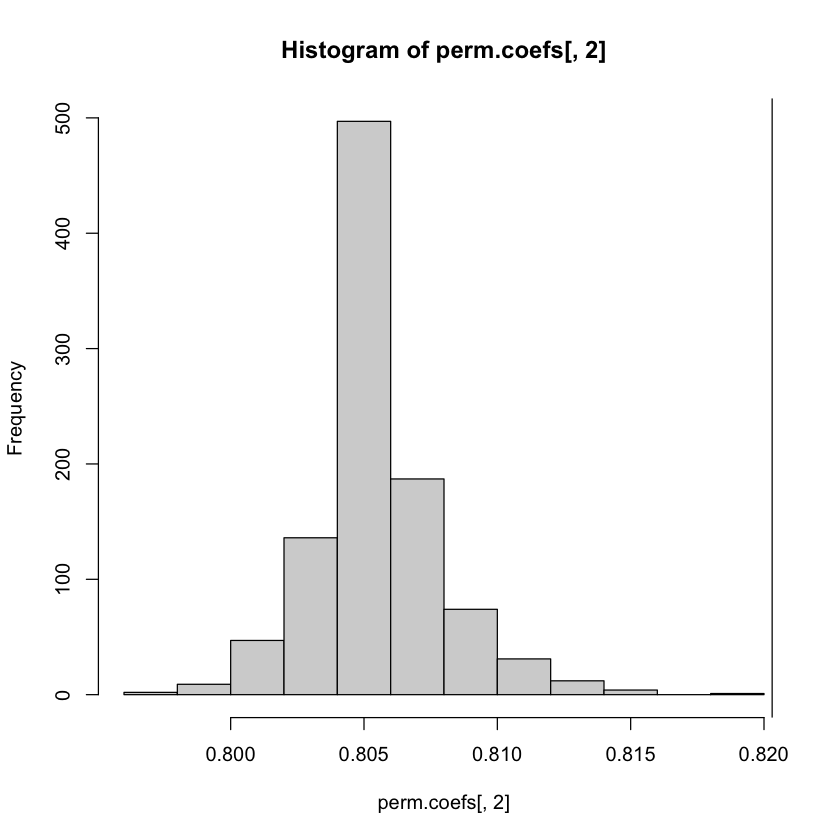

In [ ]:
hist(perm.coefs[,2])
abline(v = accr)

How much does the grey matter volume influence the prediction accuracy of the model?

> Grey matter volume influences and reduces the prediction accuracy, by shifting the prediction accuracy overall toward 0.805 from 0.82, i.e., by 2%.

---
## 5. Reflection (1 point)

Differentiate the bootstrap from a permutation test. Describe each and when is it appropriate to each.

> Permutation tests resamples and assumes no relationship between the IVs, and shuffles the order of the samples. Bootstrapping samples with replacement for a test statistic, and does not shuffle the order of the dataset.
> Permutation tests are appropriate for when the researcher is interested in the results of the data, assuming that there is no relationship between the variables. Bootstrapping, on the other hand, is appropriate for when the researcher is interested in the range of values that can be obtained from the existing sample.

**DUE:** 5pm EST, March 26, 2025

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*